In [50]:
# Libraries
from sys import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [31]:
### Data Loading

df = pd.read_csv("stage4_features.csv")

df.head()

,scenario_id,split,class_name,send_v_rms_a_v,send_v_rms_b_v,send_v_rms_c_v,send_i_rms_a_a,send_i_rms_b_a,send_i_rms_c_a,send_v_rms_ratio_a,...,receive_v_spectral_entropy_mean,receive_v_spectral_entropy_max,receive_v_fundamental_residual_ratio_mean,receive_v_crest_factor_mean,receive_v_flatline_fraction_mean,receive_i_spectral_entropy_mean,receive_i_spectral_entropy_max,receive_i_fundamental_residual_ratio_mean,receive_i_crest_factor_mean,receive_i_flatline_fraction_mean
0,stage4_006324,train,CA,116648.243328,132606.498764,117525.522755,2036.110915,226.360257,2063.679653,0.882780,...,0.115058,0.118373,0.055208,1.378418,0.010860,0.114468,0.116752,0.054456,1.608260,0.003342
1,stage4_000708,train,Healthy,132162.440207,132008.443957,131239.898341,174.127951,173.272842,173.452631,1.000069,...,0.113745,0.117383,0.013537,1.426633,0.001671,0.113762,0.116331,0.013120,1.424010,0.000835
2,stage4_003544,train,CG,131777.450133,132478.795791,77860.328031,235.813976,263.024186,2145.019828,0.999050,...,0.185925,0.330113,0.209468,1.618260,0.010025,0.220438,0.428927,0.057327,1.502808,0.001671
3,stage4_002495,validation,BG,131254.093122,80240.971916,130988.264764,327.626774,3477.002206,300.159245,0.998033,...,0.163333,0.260361,0.165770,1.637747,0.013367,0.164593,0.263828,0.044094,1.449196,0.006683
4,stage4_004132,train,AB,131671.968270,124426.084239,132221.749750,1327.319630,1300.746614,200.872834,0.990787,...,0.115309,0.117159,0.026249,1.438159,0.004177,0.114655,0.119182,0.029347,1.424801,0.002506


In [32]:
cols_to_drop = ['scenario_id']
df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

df.head()

,split,class_name,send_v_rms_a_v,send_v_rms_b_v,send_v_rms_c_v,send_i_rms_a_a,send_i_rms_b_a,send_i_rms_c_a,send_v_rms_ratio_a,send_v_rms_ratio_b,...,receive_v_spectral_entropy_mean,receive_v_spectral_entropy_max,receive_v_fundamental_residual_ratio_mean,receive_v_crest_factor_mean,receive_v_flatline_fraction_mean,receive_i_spectral_entropy_mean,receive_i_spectral_entropy_max,receive_i_fundamental_residual_ratio_mean,receive_i_crest_factor_mean,receive_i_flatline_fraction_mean
0,train,CA,116648.243328,132606.498764,117525.522755,2036.110915,226.360257,2063.679653,0.882780,1.003292,...,0.115058,0.118373,0.055208,1.378418,0.010860,0.114468,0.116752,0.054456,1.608260,0.003342
1,train,Healthy,132162.440207,132008.443957,131239.898341,174.127951,173.272842,173.452631,1.000069,0.999684,...,0.113745,0.117383,0.013537,1.426633,0.001671,0.113762,0.116331,0.013120,1.424010,0.000835
2,train,CG,131777.450133,132478.795791,77860.328031,235.813976,263.024186,2145.019828,0.999050,0.999888,...,0.185925,0.330113,0.209468,1.618260,0.010025,0.220438,0.428927,0.057327,1.502808,0.001671
3,validation,BG,131254.093122,80240.971916,130988.264764,327.626774,3477.002206,300.159245,0.998033,0.614567,...,0.163333,0.260361,0.165770,1.637747,0.013367,0.164593,0.263828,0.044094,1.449196,0.006683
4,train,AB,131671.968270,124426.084239,132221.749750,1327.319630,1300.746614,200.872834,0.990787,0.945380,...,0.115309,0.117159,0.026249,1.438159,0.004177,0.114655,0.119182,0.029347,1.424801,0.002506


In [40]:
# Data Analysis
# List features variance
X = df[['send_v_rms_ratio_a', 'send_v_rms_ratio_b', 'send_v_rms_ratio_c', 
        'send_i_rms_ratio_a', 'send_i_rms_ratio_b', 'send_i_rms_ratio_c',
        'send_v0_v1_ratio', 'send_v2_v1_ratio', 'send_i0_i1_ratio', 'send_i2_i1_ratio']]

y = df['class_name']

X.var().sort_values(ascending=False)

send_i_rms_ratio_a    13.592902
send_i_rms_ratio_b    13.573761
send_i_rms_ratio_c    13.534582
send_i2_i1_ratio       0.095035
send_i0_i1_ratio       0.077656
send_v_rms_ratio_a     0.026141
send_v_rms_ratio_c     0.025845
send_v_rms_ratio_b     0.025732
send_v2_v1_ratio       0.016683
send_v0_v1_ratio       0.005059
dtype: float64

In [41]:
# Logistic Regression

train = df["split"].eq("train")
validation = df["split"].eq("validation")
test = df["split"].eq("test")

X_train, y_train = X.loc[train], y.loc[train]
X_val, y_val = X.loc[validation], y.loc[validation]
X_test, y_test = X.loc[test], y.loc[test]

print(X.columns.tolist())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(solver='lbfgs', max_iter=200)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluate the model
for split_name, X_split, y_split in [
    ("validation", X_val_scaled, y_val),
    ("test", X_test_scaled, y_test),
    ("ood_test", scaler.transform(X.loc[df["split"].eq("ood_test")]), y.loc[df["split"].eq("ood_test")])
]:
    y_pred = model.predict(X_split)
    print(split_name, accuracy_score(y_split, y_pred))
    print(classification_report(y_split, y_pred))

['send_v_rms_ratio_a', 'send_v_rms_ratio_b', 'send_v_rms_ratio_c', 'send_i_rms_ratio_a', 'send_i_rms_ratio_b', 'send_i_rms_ratio_c', 'send_v0_v1_ratio', 'send_v2_v1_ratio', 'send_i0_i1_ratio', 'send_i2_i1_ratio']
validation 0.9921212121212121
              precision    recall  f1-score   support

          AB       0.96      1.00      0.98       150
         ABC       1.00      1.00      1.00       150
         ABG       1.00      0.96      0.98       150
          AG       1.00      1.00      1.00       150
          BC       0.96      1.00      0.98       150
         BCG       1.00      0.96      0.98       150
          BG       1.00      1.00      1.00       150
          CA       0.99      1.00      1.00       150
         CAG       1.00      0.99      1.00       150
          CG       1.00      1.00      1.00       150
     Healthy       1.00      1.00      1.00       150

    accuracy                           0.99      1650
   macro avg       0.99      0.99      0.99      1650

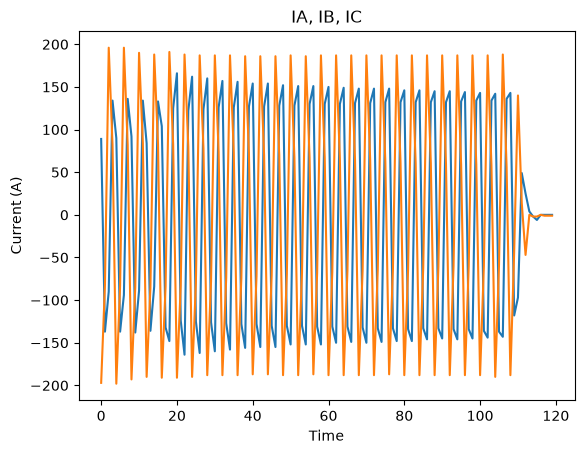

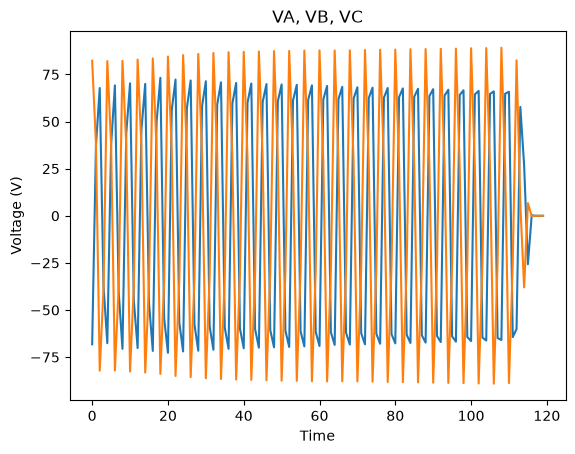

In [39]:
df_exercise5 = pd.read_csv("Exercise5_Filtered.csv");

# plot IA from df_exercise5
plt.figure(1);
plt.plot(df_exercise5['IA']);
plt.plot(df_exercise5['IB']);
#plt.plot(df_exercise5['IC']);
plt.title('IA, IB, IC');
plt.xlabel('Time');
plt.ylabel('Current (A)');


plt.figure(2);
plt.plot(df_exercise5['VA(kV)']);
plt.plot(df_exercise5['VB(kV)']);
#plt.plot(df_exercise5['VC(kV)']);
plt.title('VA, VB, VC');
plt.xlabel('Time');
plt.ylabel('Voltage (V)');


In [45]:
def rms(x):
    return np.sqrt(np.mean(np.asarray(x) ** 2))

def imbalance_pct(values):
    values = np.asarray(values, dtype=float)
    return (values.max() - values.min()) / values.mean() * 100

def safe_ratio(num, den):
    return num / den if abs(den) > 1e-12 else 0.0

def fundamental_phasor(x, samples_per_cycle=16):
    x = np.asarray(x, dtype=float)
    n_complete = len(x) // samples_per_cycle * samples_per_cycle
    x = x[:n_complete]

    n = np.arange(len(x))
    angle = 2j * np.pi * n / samples_per_cycle

    return np.sqrt(2) * np.mean(x * np.exp(angle))

def sequence_components(a_phase, b_phase, c_phase):
    alpha = np.exp(2j * np.pi / 3)

    zero = (a_phase + b_phase + c_phase) / 3
    positive = (a_phase + alpha * b_phase + alpha**2 * c_phase) / 3
    negative = (a_phase + alpha**2 * b_phase + alpha * c_phase) / 3

    return zero, positive, negative

def make_stage4_features_from_exercise5(path, feature_order, samples_per_cycle=16, event_start_sample=None, window_cycles=1):
    df = pd.read_csv(path)

    # Convert kV to V because stage4_features uses volts.
    va = df["VA(kV)"] * 1000
    vb = df["VB(kV)"] * 1000
    vc = df["VC(kV)"] * 1000

    ia = df["IA"]
    ib = df["IB"]
    ic = df["IC"]

    window_samples = samples_per_cycle * window_cycles
    if event_start_sample is None:
        feature_slice = slice(None)
        baseline_slice = slice(0, samples_per_cycle)
    else:
        feature_start = int(event_start_sample)
        feature_stop = min(feature_start + window_samples, len(df))
        baseline_stop = feature_start
        baseline_start = max(0, baseline_stop - samples_per_cycle)

        if feature_stop - feature_start < samples_per_cycle:
            raise ValueError("Feature window must contain at least one complete cycle.")
        if baseline_stop - baseline_start < samples_per_cycle:
            raise ValueError("Baseline window must contain at least one complete pre-event cycle.")

        feature_slice = slice(feature_start, feature_stop)
        baseline_slice = slice(baseline_start, baseline_stop)

    va_feature, vb_feature, vc_feature = va.iloc[feature_slice], vb.iloc[feature_slice], vc.iloc[feature_slice]
    ia_feature, ib_feature, ic_feature = ia.iloc[feature_slice], ib.iloc[feature_slice], ic.iloc[feature_slice]

    va_baseline, vb_baseline, vc_baseline = va.iloc[baseline_slice], vb.iloc[baseline_slice], vc.iloc[baseline_slice]
    ia_baseline, ib_baseline, ic_baseline = ia.iloc[baseline_slice], ib.iloc[baseline_slice], ic.iloc[baseline_slice]

    v_rms = np.array([rms(va_feature), rms(vb_feature), rms(vc_feature)])
    i_rms = np.array([rms(ia_feature), rms(ib_feature), rms(ic_feature)])

    v_baseline_rms = np.array([
        rms(va_baseline),
        rms(vb_baseline),
        rms(vc_baseline),
    ])
    i_baseline_rms = np.array([
        rms(ia_baseline),
        rms(ib_baseline),
        rms(ic_baseline),
    ])

    va_ph = fundamental_phasor(va_feature, samples_per_cycle)
    vb_ph = fundamental_phasor(vb_feature, samples_per_cycle)
    vc_ph = fundamental_phasor(vc_feature, samples_per_cycle)

    ia_ph = fundamental_phasor(ia_feature, samples_per_cycle)
    ib_ph = fundamental_phasor(ib_feature, samples_per_cycle)
    ic_ph = fundamental_phasor(ic_feature, samples_per_cycle)

    v0, v1, v2 = sequence_components(va_ph, vb_ph, vc_ph)
    i0, i1, i2 = sequence_components(ia_ph, ib_ph, ic_ph)

    row = {
        "send_v_rms_ratio_a": safe_ratio(v_rms[0], v_baseline_rms[0]),
        "send_v_rms_ratio_b": safe_ratio(v_rms[1], v_baseline_rms[1]),
        "send_v_rms_ratio_c": safe_ratio(v_rms[2], v_baseline_rms[2]),
        "send_i_rms_ratio_a": safe_ratio(i_rms[0], i_baseline_rms[0]),
        "send_i_rms_ratio_b": safe_ratio(i_rms[1], i_baseline_rms[1]),
        "send_i_rms_ratio_c": safe_ratio(i_rms[2], i_baseline_rms[2]),
        "send_v0_v1_ratio": safe_ratio(abs(v0), abs(v1)),
        "send_v2_v1_ratio": safe_ratio(abs(v2), abs(v1)),
        "send_i0_i1_ratio": safe_ratio(abs(i0), abs(i1)),
        "send_i2_i1_ratio": safe_ratio(abs(i2), abs(i1)),
    }

    return pd.DataFrame([row])[feature_order]

In [46]:
exercise5_features = make_stage4_features_from_exercise5(
    "Exercise5.csv",
    feature_order=X.columns,
    samples_per_cycle=16,
    event_start_sample=20,
    window_cycles=1
)

exercise5_scaled = scaler.transform(exercise5_features)

prediction = model.predict(exercise5_scaled)

prediction

array(['Healthy'], dtype=object)

In [44]:
model.predict(exercise5_scaled)

array(['Healthy'], dtype=object)

## Unsupervised Learning Analysis

In [ ]:
IF_Model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)

IF_Model.fit(X)



predictions = IF_Model.predict(X)

anomaly_scores = IF_Model.decision_function(X)

# 6. Organize into a clean DataFrame for inspection
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Is_Anomaly'] = predictions
df['Anomaly_Score'] = anomaly_scores

# Display the detected anomalies
print(df[df['Is_Anomaly'] == -1])

       Feature_1  Feature_2  Is_Anomaly  Anomaly_Score
20           NaN        NaN          -1      -0.033642
85           NaN        NaN          -1      -0.030838
141          NaN        NaN          -1      -0.018105
238          NaN        NaN          -1      -0.094093
240          NaN        NaN          -1      -0.017137
...          ...        ...         ...            ...
10793        NaN        NaN          -1      -0.024581
10847        NaN        NaN          -1      -0.060565
10858        NaN        NaN          -1      -0.012533
10974        NaN        NaN          -1      -0.062682
10983        NaN        NaN          -1      -0.086529

[327 rows x 4 columns]
